C:\Users\favou\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Project folder: C:\Users\favou\Desktop\Data Science

Dataset shape: (7671, 53)

Regression dataset sizes:
Training: (5036, 53)
Validation: (988, 53)
Test: (952, 53)

Persistence baseline - 2023 validation:
Observations: 961
MAE: 3.313
RMSE: 7.897
R²: 0.493

Initial 2023 validation results:
           Model    MAE   RMSE     R2
Ridge Regression 3.2843 6.5974 0.6416
   Random Forest 3.3589 6.9343 0.6040
         XGBoost 3.4920 7.2337 0.5691

Common-row 2023 validation comparison:
           Model    MAE   RMSE     R2
     Persistence 3.3128 7.8965 0.4934
Ridge Regression 3.2360 6.5857 0.6477
   Random Forest 3.3338 6.9597 0.6065
         XGBoost 3.4625 7.2600 0.5718

Ridge tuning:
 Alpha    MAE   RMSE     R2
  0.01 3.2357 6.5857 0.6477
  0.10 3.2358 6.5857 0.6477
  1.00 3.2360 6.5857 0.6477
 10.00 3.2388 6.5862 0.6476
100.00 3.2739 6.6045 0.6456

Random Forest tuning:
 n_estimators  max_depth  min_samples_leaf    MAE   RMSE     R2
          300        NaN                 4 3.2840 6.8978 

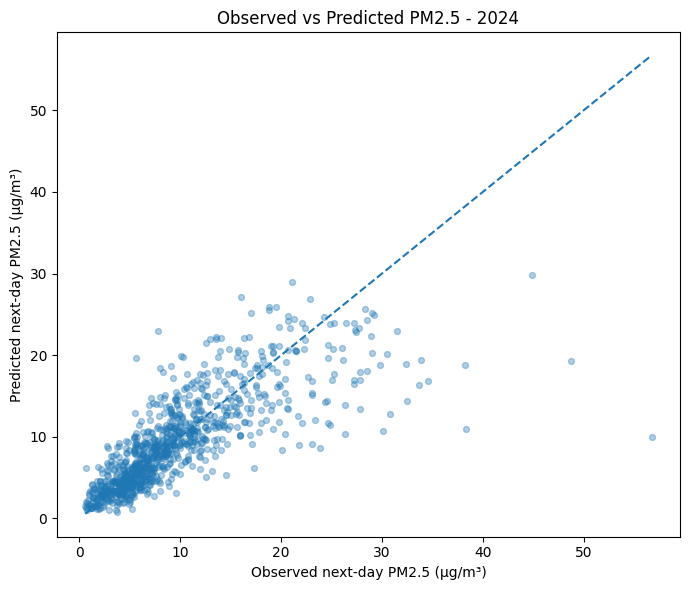

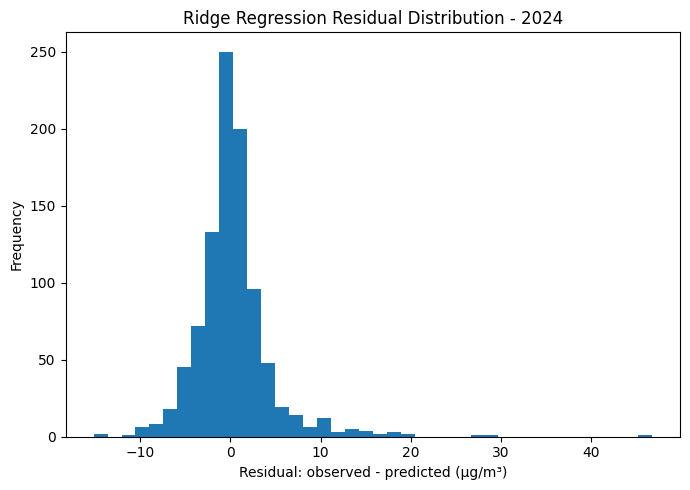

Background dataset has 952 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=952 when initializing the masker.


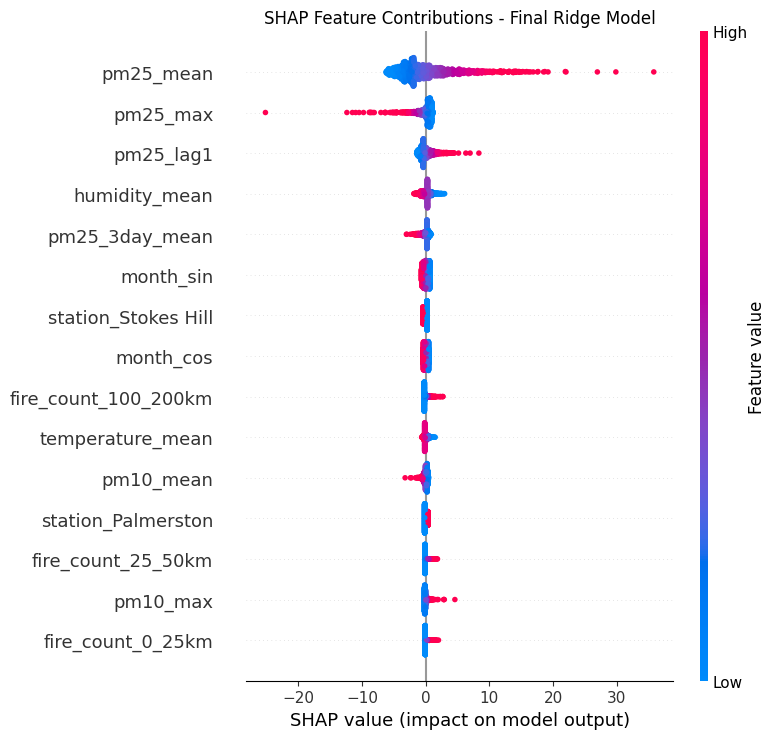


Regression predictions saved: (952, 5)
Final Ridge model saved.
SHAP plot saved: ridge_shap_beeswarm_2024.png

Regression pipeline complete.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import joblib
import shap

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from xgboost import XGBRegressor


# Find the model-ready dataset
possible_folders = [
    Path.cwd(),
    Path.cwd() / "Data Science",
    Path.home() / "Desktop" / "Data Science",
]

project_folder = None

for folder in possible_folders:
    checkpoint = folder / "Fire2Air_model_ready_checkpoint.csv"

    if checkpoint.exists():
        project_folder = folder
        break

if project_folder is None:
    raise FileNotFoundError(
        "Fire2Air_model_ready_checkpoint.csv could not be found. "
        "Run 01_data_preparation.ipynb first."
    )

print("Project folder:", project_folder)


# Load the shared model-ready dataset
integrated_daily = pd.read_csv(
    project_folder / "Fire2Air_model_ready_checkpoint.csv",
    parse_dates=["date"]
)

print("\nDataset shape:", integrated_daily.shape)


# Define the regression target
regression_target = "target_pm25_next_day"


# Use the shared predictor set
model_features = [
    "station",
    "pm25_mean",
    "pm25_max",
    "pm10_mean",
    "pm10_max",
    "humidity_mean",
    "temperature_mean",
    "wind_speed_mean",
    "pressure_mean",
    "wind_dir_sin_mean",
    "wind_dir_cos_mean",
    "fire_count_0_25km",
    "fire_count_25_50km",
    "fire_count_50_100km",
    "fire_count_100_200km",
    "frp_sum_0_200km",
    "month_sin",
    "month_cos",
    "pm25_lag1",
    "pm25_3day_mean"
]


# Create chronological development periods
train_data = integrated_daily[
    integrated_daily["date"].dt.year <= 2022
].copy()

validation_data = integrated_daily[
    integrated_daily["date"].dt.year == 2023
].copy()

test_data = integrated_daily[
    integrated_daily["date"].dt.year == 2024
].copy()


# Keep rows with an available regression target
train_reg = train_data[
    train_data[regression_target].notna()
].copy()

validation_reg = validation_data[
    validation_data[regression_target].notna()
].copy()

test_reg = test_data[
    test_data[regression_target].notna()
].copy()


print("\nRegression dataset sizes:")
print("Training:", train_reg.shape)
print("Validation:", validation_reg.shape)
print("Test:", test_reg.shape)


# Separate predictors and targets
X_train = train_reg[model_features]
y_train = train_reg[regression_target]

X_validation = validation_reg[model_features]
y_validation = validation_reg[regression_target]

X_test = test_reg[model_features]
y_test = test_reg[regression_target]


# Separate categorical and numerical predictors
categorical_features = ["station"]

numeric_features = [
    feature
    for feature in model_features
    if feature not in categorical_features
]


# Preprocess station
categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "onehot",
            OneHotEncoder(handle_unknown="ignore")
        )
    ]
)


# Ridge requires numerical scaling
ridge_numeric_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)


ridge_preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            categorical_pipeline,
            categorical_features
        ),
        (
            "numeric",
            ridge_numeric_pipeline,
            numeric_features
        )
    ]
)


# Tree models only require missing-value imputation
tree_numeric_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        )
    ]
)


tree_preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            categorical_pipeline,
            categorical_features
        ),
        (
            "numeric",
            tree_numeric_pipeline,
            numeric_features
        )
    ]
)


# Regression evaluation function
def regression_metrics(
    y_true,
    predictions
):

    return {
        "MAE": mean_absolute_error(
            y_true,
            predictions
        ),
        "RMSE": np.sqrt(
            mean_squared_error(
                y_true,
                predictions
            )
        ),
        "R2": r2_score(
            y_true,
            predictions
        )
    }


# Persistence baseline
# Current-day PM2.5 is used as the next-day prediction
persistence_mask = (
    validation_reg["pm25_mean"].notna()
)

persistence_actual = (
    validation_reg.loc[
        persistence_mask,
        regression_target
    ]
)

persistence_predictions = (
    validation_reg.loc[
        persistence_mask,
        "pm25_mean"
    ]
)

persistence_results = regression_metrics(
    persistence_actual,
    persistence_predictions
)


print("\nPersistence baseline - 2023 validation:")
print(
    f"Observations: {persistence_mask.sum()}"
)
print(
    f"MAE: {persistence_results['MAE']:.3f}"
)
print(
    f"RMSE: {persistence_results['RMSE']:.3f}"
)
print(
    f"R²: {persistence_results['R2']:.3f}"
)


# Define initial candidate models
ridge_initial = Pipeline(
    steps=[
        (
            "preprocessor",
            ridge_preprocessor
        ),
        (
            "model",
            Ridge(alpha=1.0)
        )
    ]
)


rf_initial = Pipeline(
    steps=[
        (
            "preprocessor",
            tree_preprocessor
        ),
        (
            "model",
            RandomForestRegressor(
                n_estimators=300,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)


xgb_initial = Pipeline(
    steps=[
        (
            "preprocessor",
            tree_preprocessor
        ),
        (
            "model",
            XGBRegressor(
                n_estimators=300,
                learning_rate=0.05,
                max_depth=3,
                objective="reg:squarederror",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)


initial_models = {
    "Ridge Regression": ridge_initial,
    "Random Forest": rf_initial,
    "XGBoost": xgb_initial
}


# Train and evaluate initial models
initial_results = []

for model_name, model in initial_models.items():

    model.fit(
        X_train,
        y_train
    )

    predictions = model.predict(
        X_validation
    )

    metrics = regression_metrics(
        y_validation,
        predictions
    )

    metrics["Model"] = model_name

    initial_results.append(metrics)


initial_results = pd.DataFrame(
    initial_results
)[
    [
        "Model",
        "MAE",
        "RMSE",
        "R2"
    ]
]


print("\nInitial 2023 validation results:")
print(
    initial_results
    .round(4)
    .to_string(index=False)
)


# Compare all initial models on the same validation rows
common_validation_mask = (
    validation_reg["pm25_mean"].notna()
)

X_validation_common = (
    X_validation.loc[
        common_validation_mask
    ]
)

y_validation_common = (
    y_validation.loc[
        common_validation_mask
    ]
)


common_results = [
    {
        "Model": "Persistence",
        **regression_metrics(
            y_validation_common,
            validation_reg.loc[
                common_validation_mask,
                "pm25_mean"
            ]
        )
    }
]


for model_name, model in initial_models.items():

    predictions = model.predict(
        X_validation_common
    )

    common_results.append(
        {
            "Model": model_name,
            **regression_metrics(
                y_validation_common,
                predictions
            )
        }
    )


common_results = pd.DataFrame(
    common_results
)


print("\nCommon-row 2023 validation comparison:")
print(
    common_results
    .round(4)
    .to_string(index=False)
)


# Tune Ridge regularisation strength
ridge_alphas = [
    0.01,
    0.1,
    1.0,
    10.0,
    100.0
]

ridge_tuning_results = []

for alpha in ridge_alphas:

    model = Pipeline(
        steps=[
            (
                "preprocessor",
                ridge_preprocessor
            ),
            (
                "model",
                Ridge(alpha=alpha)
            )
        ]
    )

    model.fit(
        X_train,
        y_train
    )

    predictions = model.predict(
        X_validation_common
    )

    metrics = regression_metrics(
        y_validation_common,
        predictions
    )

    ridge_tuning_results.append(
        {
            "Alpha": alpha,
            **metrics
        }
    )


ridge_tuning_results = pd.DataFrame(
    ridge_tuning_results
).sort_values(
    "RMSE"
)


print("\nRidge tuning:")
print(
    ridge_tuning_results
    .round(4)
    .to_string(index=False)
)


# Tune Random Forest
rf_settings = [
    {
        "n_estimators": 300,
        "max_depth": None,
        "min_samples_leaf": 1
    },
    {
        "n_estimators": 300,
        "max_depth": 10,
        "min_samples_leaf": 4
    },
    {
        "n_estimators": 300,
        "max_depth": 15,
        "min_samples_leaf": 4
    },
    {
        "n_estimators": 300,
        "max_depth": None,
        "min_samples_leaf": 4
    }
]

rf_tuning_results = []

for settings in rf_settings:

    model = Pipeline(
        steps=[
            (
                "preprocessor",
                tree_preprocessor
            ),
            (
                "model",
                RandomForestRegressor(
                    n_estimators=settings[
                        "n_estimators"
                    ],
                    max_depth=settings[
                        "max_depth"
                    ],
                    min_samples_leaf=settings[
                        "min_samples_leaf"
                    ],
                    random_state=42,
                    n_jobs=-1
                )
            )
        ]
    )

    model.fit(
        X_train,
        y_train
    )

    predictions = model.predict(
        X_validation_common
    )

    metrics = regression_metrics(
        y_validation_common,
        predictions
    )

    rf_tuning_results.append(
        {
            **settings,
            **metrics
        }
    )


rf_tuning_results = pd.DataFrame(
    rf_tuning_results
).sort_values(
    "RMSE"
)


print("\nRandom Forest tuning:")
print(
    rf_tuning_results
    .round(4)
    .to_string(index=False)
)


# Tune XGBoost
xgb_settings = [
    {
        "n_estimators": 100,
        "learning_rate": 0.05,
        "max_depth": 2
    },
    {
        "n_estimators": 200,
        "learning_rate": 0.05,
        "max_depth": 2
    },
    {
        "n_estimators": 300,
        "learning_rate": 0.05,
        "max_depth": 2
    },
    {
        "n_estimators": 200,
        "learning_rate": 0.05,
        "max_depth": 3
    }
]

xgb_tuning_results = []

for settings in xgb_settings:

    model = Pipeline(
        steps=[
            (
                "preprocessor",
                tree_preprocessor
            ),
            (
                "model",
                XGBRegressor(
                    n_estimators=settings[
                        "n_estimators"
                    ],
                    learning_rate=settings[
                        "learning_rate"
                    ],
                    max_depth=settings[
                        "max_depth"
                    ],
                    objective="reg:squarederror",
                    random_state=42,
                    n_jobs=-1
                )
            )
        ]
    )

    model.fit(
        X_train,
        y_train
    )

    predictions = model.predict(
        X_validation_common
    )

    metrics = regression_metrics(
        y_validation_common,
        predictions
    )

    xgb_tuning_results.append(
        {
            **settings,
            **metrics
        }
    )


xgb_tuning_results = pd.DataFrame(
    xgb_tuning_results
).sort_values(
    "RMSE"
)


print("\nXGBoost tuning:")
print(
    xgb_tuning_results
    .round(4)
    .to_string(index=False)
)


# Compare the best validation configuration from each model family
best_ridge = ridge_tuning_results.iloc[0]
best_rf = rf_tuning_results.iloc[0]
best_xgb = xgb_tuning_results.iloc[0]


selected_validation_results = pd.DataFrame(
    [
        {
            "Model": "Ridge Regression",
            "MAE": best_ridge["MAE"],
            "RMSE": best_ridge["RMSE"],
            "R2": best_ridge["R2"]
        },
        {
            "Model": "Random Forest",
            "MAE": best_rf["MAE"],
            "RMSE": best_rf["RMSE"],
            "R2": best_rf["R2"]
        },
        {
            "Model": "XGBoost",
            "MAE": best_xgb["MAE"],
            "RMSE": best_xgb["RMSE"],
            "R2": best_xgb["R2"]
        }
    ]
)


print("\nSelected 2023 validation comparison:")
print(
    selected_validation_results
    .round(4)
    .to_string(index=False)
)


# Freeze the selected model using validation performance
final_ridge_model = Pipeline(
    steps=[
        (
            "preprocessor",
            ridge_preprocessor
        ),
        (
            "model",
            Ridge(alpha=0.01)
        )
    ]
)


print("\nSelected final model: Ridge Regression")
print("Selected alpha: 0.01")


# Refit the selected model using 2018-2023 development data
development_reg = pd.concat(
    [
        train_reg,
        validation_reg
    ],
    ignore_index=True
)

X_development = (
    development_reg[
        model_features
    ]
)

y_development = (
    development_reg[
        regression_target
    ]
)


final_ridge_model.fit(
    X_development,
    y_development
)


print(
    "Final refit observations:",
    len(development_reg)
)


# Evaluate once on the unseen 2024 test set
test_predictions = (
    final_ridge_model.predict(
        X_test
    )
)

test_metrics = regression_metrics(
    y_test,
    test_predictions
)


print("\nFinal 2024 regression performance:")
print(
    f"MAE: {test_metrics['MAE']:.3f}"
)
print(
    f"RMSE: {test_metrics['RMSE']:.3f}"
)
print(
    f"R²: {test_metrics['R2']:.3f}"
)


# Fair comparison with persistence on common 2024 rows
test_common_mask = (
    test_reg["pm25_mean"].notna()
)

y_test_common = (
    y_test.loc[
        test_common_mask
    ]
)

persistence_test_predictions = (
    test_reg.loc[
        test_common_mask,
        "pm25_mean"
    ]
)

ridge_test_common_predictions = (
    final_ridge_model.predict(
        X_test.loc[
            test_common_mask
        ]
    )
)


persistence_test_metrics = regression_metrics(
    y_test_common,
    persistence_test_predictions
)

ridge_test_common_metrics = regression_metrics(
    y_test_common,
    ridge_test_common_predictions
)


test_common_comparison = pd.DataFrame(
    [
        {
            "Model": "Persistence",
            **persistence_test_metrics
        },
        {
            "Model": "Ridge Regression",
            **ridge_test_common_metrics
        }
    ]
)


print("\nCommon-row 2024 comparison:")
print(
    "Observations:",
    test_common_mask.sum()
)

print(
    test_common_comparison
    .round(4)
    .to_string(index=False)
)


# Calculate residuals
residuals = (
    y_test.to_numpy()
    - test_predictions
)


print("\nResidual diagnostics:")
print(
    "Mean residual:",
    round(
        residuals.mean(),
        3
    )
)

print(
    "Median residual:",
    round(
        np.median(residuals),
        3
    )
)

print(
    "Minimum residual:",
    round(
        residuals.min(),
        3
    )
)

print(
    "Maximum residual:",
    round(
        residuals.max(),
        3
    )
)


# Compare performance on normal and elevated PM2.5 days
normal_mask = (
    y_test.to_numpy() <= 25
)

elevated_mask = (
    y_test.to_numpy() > 25
)


normal_metrics = regression_metrics(
    y_test.to_numpy()[normal_mask],
    test_predictions[normal_mask]
)

elevated_metrics = regression_metrics(
    y_test.to_numpy()[elevated_mask],
    test_predictions[elevated_mask]
)


print("\nObserved next-day PM2.5 <= 25:")
print(
    "Observations:",
    normal_mask.sum()
)
print(
    f"MAE: {normal_metrics['MAE']:.3f}"
)
print(
    f"RMSE: {normal_metrics['RMSE']:.3f}"
)
print(
    "Mean residual:",
    round(
        residuals[normal_mask].mean(),
        3
    )
)


print("\nObserved next-day PM2.5 > 25:")
print(
    "Observations:",
    elevated_mask.sum()
)
print(
    f"MAE: {elevated_metrics['MAE']:.3f}"
)
print(
    f"RMSE: {elevated_metrics['RMSE']:.3f}"
)
print(
    "Mean residual:",
    round(
        residuals[elevated_mask].mean(),
        3
    )
)


# Plot observed against predicted PM2.5
plt.figure(figsize=(7, 6))

plt.scatter(
    y_test,
    test_predictions,
    alpha=0.35,
    s=18
)

plot_min = min(
    y_test.min(),
    test_predictions.min()
)

plot_max = max(
    y_test.max(),
    test_predictions.max()
)

plt.plot(
    [plot_min, plot_max],
    [plot_min, plot_max],
    linestyle="--"
)

plt.xlabel(
    "Observed next-day PM2.5 (µg/m³)"
)

plt.ylabel(
    "Predicted next-day PM2.5 (µg/m³)"
)

plt.title(
    "Observed vs Predicted PM2.5 - 2024"
)

plt.tight_layout()
plt.show()


# Plot residual distribution
plt.figure(figsize=(7, 5))

plt.hist(
    residuals,
    bins=40
)

plt.xlabel(
    "Residual: observed - predicted (µg/m³)"
)

plt.ylabel("Frequency")

plt.title(
    "Ridge Regression Residual Distribution - 2024"
)

plt.tight_layout()
plt.show()


# Prepare transformed data for SHAP
final_preprocessor = (
    final_ridge_model
    .named_steps["preprocessor"]
)

final_ridge = (
    final_ridge_model
    .named_steps["model"]
)

X_test_transformed = (
    final_preprocessor.transform(
        X_test
    )
)


# Retrieve transformed feature names
transformed_feature_names = (
    final_preprocessor
    .get_feature_names_out()
)

# Make feature names easier to read
clean_feature_names = [
    name
    .replace("categorical__", "")
    .replace("numeric__", "")
    for name in transformed_feature_names
]


# Explain the final linear model
explainer = shap.LinearExplainer(
    final_ridge,
    X_test_transformed
)

shap_values = explainer(
    X_test_transformed
)


# Create and save the SHAP beeswarm plot
plt.figure()

shap.summary_plot(
    shap_values.values,
    X_test_transformed,
    feature_names=clean_feature_names,
    show=False,
    max_display=15
)

plt.title(
    "SHAP Feature Contributions - Final Ridge Model"
)

plt.tight_layout()

shap_output = (
    project_folder
    / "ridge_shap_beeswarm_2024.png"
)

plt.savefig(
    shap_output,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# Save 2024 regression predictions
regression_predictions = pd.DataFrame(
    {
        "date": test_reg["date"].values,
        "station": test_reg["station"].values,
        "observed_pm25_next_day": y_test.values,
        "predicted_pm25_next_day": test_predictions,
        "residual": residuals
    }
)


regression_predictions.to_csv(
    project_folder
    / "Fire2Air_regression_predictions_2024.csv",
    index=False
)


# Save the final fitted Ridge pipeline
joblib.dump(
    final_ridge_model,
    project_folder
    / "Fire2Air_final_ridge_model.joblib"
)


print(
    "\nRegression predictions saved:",
    regression_predictions.shape
)

print(
    "Final Ridge model saved."
)

print(
    "SHAP plot saved:",
    shap_output.name
)

print(
    "\nRegression pipeline complete."
)